In [24]:
import numpy as np

fname = "results_px_0.0_Lx_10_Nd_1000_NT_3000_with_err.npz"
data = np.load(fname)

# どんなデータが入っているか（キーの一覧）
print("keys:", data.files)

# 各キーの中身の形状や型を確認
for k in data.files:
    arr = data[k]
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")


keys: ['pg', 'TEE_ave', 'TEE_err', 'TEE_var', 'R2x_ave', 'R2x_err', 'R2x_var', 'R2z_ave', 'R2z_err', 'R2z_var', 'R2x_loop_ave', 'R2x_loop_err', 'R2x_loop_var', 'R2z_loop_ave', 'R2z_loop_err', 'R2z_loop_var', 'dep_x_ave', 'dep_x_err', 'dep_x_var', 'dep_z_ave', 'dep_z_err', 'dep_z_var', 'R2z_loop_var_err', 'R2z_loop_var_Neff']
pg: shape=(41,), dtype=float64
TEE_ave: shape=(41,), dtype=float64
TEE_err: shape=(41,), dtype=float64
TEE_var: shape=(41,), dtype=float64
R2x_ave: shape=(41,), dtype=float64
R2x_err: shape=(41,), dtype=float64
R2x_var: shape=(41,), dtype=float64
R2z_ave: shape=(41,), dtype=float64
R2z_err: shape=(41,), dtype=float64
R2z_var: shape=(41,), dtype=float64
R2x_loop_ave: shape=(41,), dtype=float64
R2x_loop_err: shape=(41,), dtype=float64
R2x_loop_var: shape=(41,), dtype=float64
R2z_loop_ave: shape=(41,), dtype=float64
R2z_loop_err: shape=(41,), dtype=float64
R2z_loop_var: shape=(41,), dtype=float64
dep_x_ave: shape=(41,), dtype=float64
dep_x_err: shape=(41,), dtype=floa

In [1]:
import numpy as np
import glob, re, os
from numpy.random import default_rng

B = 1000                  # ブートストラップ反復回数（200–2000程度で調整）
rng = default_rng(123)    # 乱数種

# N_eff の定義: "Nd"（推奨, 保守的） or "NdNT"（独立なら）
N_mode = "Nd"

files = glob.glob("results_px_*_Lx_*_Nd_*_NT_*.npz")

for fn in files:
    m = re.search(r"px_([0-9.]+)_Lx_(\d+)_Nd_(\d+)_NT_(\d+)\.npz$", fn)
    if not m:
        print(f"[skip] name pattern mismatch: {fn}")
        continue
    Nd = int(m.group(3)); NT = int(m.group(4))
    N_eff = Nd if N_mode == "Nd" else Nd*NT

    data = np.load(fn)
    if "R2z_loop_var" not in data.files:
        print(f"[skip] no R2x_loop_var in {fn}")
        continue

    s2 = np.asarray(data["R2z_loop_var"], float)  # 形状: (nPg,)
    s2 = np.clip(s2, 0.0, None)
    df = max(N_eff - 1, 1)

    # χ²ブートストラップ：sigma2* を χ² から生成し、対応する s2* を作る
    # 由来: (df * s2) / sigma2 ~ χ²_df  ⇒  sigma2 = df * s2 / χ²
    # 観測 s2 を真値の近似に使い、sigma2* を生成 → そこから s2* を再構成しても良いが、
    # 実務的には「s2* = df * s2 / χ²(df)」で十分に近い分布を再現できます。
    # （s2 が真の sigma2 を近似しているとみなす近似）
    chi2_samples = rng.chisquare(df, size=(B, s2.size))
    s2_boot = (df * s2[None, :]) / chi2_samples  # 形状 (B, nPg)

    # ブートストラップ標準偏差を誤差として採用
    s2_err = s2_boot.std(axis=0, ddof=1)

    # 保存（別名ファイル）
    out = {k: data[k] for k in data.files}
    out["R2z_loop_var_err"] = s2_err.astype(float)
    out["R2z_loop_var_Neff"] = np.array(N_eff, dtype=int)

    base, ext = os.path.splitext(fn)
    out_fn = base + "_with_err" + ext
    np.savez(out_fn, **out)
    print(f"[ok] wrote {out_fn} (N_eff={N_eff}, B={B})")


[ok] wrote results_px_0.0_Lx_8_Nd_1000_NT_1920_with_err.npz (N_eff=1000, B=1000)
[skip] name pattern mismatch: results_px_0.0_Lx_6_Nd_1000_NT_1080_with_err.npz
[ok] wrote results_px_0.0_Lx_18_Nd_800_NT_9720_with_err.npz (N_eff=800, B=1000)
[skip] name pattern mismatch: results_px_0.0_Lx_12_Nd_800_NT_4320_with_err.npz
[ok] wrote results_px_0.0_Lx_12_Nd_800_NT_4320_with_err.npz (N_eff=800, B=1000)
[skip] name pattern mismatch: results_px_0.0_Lx_16_Nd_800_NT_7680_with_err.npz
[ok] wrote results_px_0.0_Lx_10_Nd_1000_NT_3000_with_err.npz (N_eff=1000, B=1000)
[skip] name pattern mismatch: results_px_0.0_Lx_8_Nd_1000_NT_1920_with_err.npz
[ok] wrote results_px_0.0_Lx_6_Nd_1000_NT_1080_with_err.npz (N_eff=1000, B=1000)
[skip] name pattern mismatch: results_px_0.0_Lx_20_Nd_800_NT_12000_with_err.npz
[skip] name pattern mismatch: results_px_0.0_Lx_10_Nd_1000_NT_3000_with_err.npz
[skip] name pattern mismatch: results_px_0.0_Lx_18_Nd_800_NT_9720_with_err.npz
[ok] wrote results_px_0.0_Lx_20_Nd_800_NT

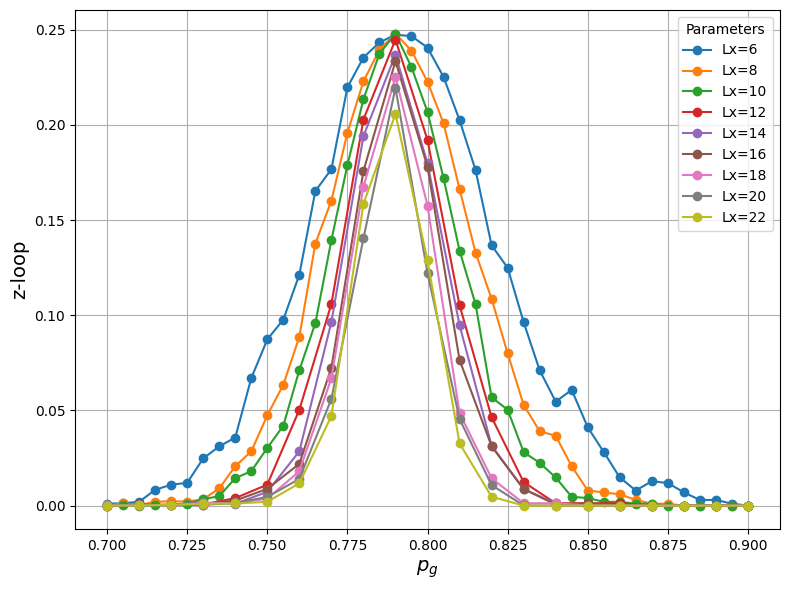

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# ファイルを取得
files = glob.glob("results_px_0.0_Lx_*_Nd_*_NT_*_with_err.npz")

# (Lx, Nd, NT, filename) のタプルを作ってソート
file_info = []
for fname in files:
    match = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)", fname)
    if match:
        Lx, Nd, NT = map(int, match.groups())
        file_info.append((Lx, Nd, NT, fname))

# Lx の昇順でソート
file_info.sort(key=lambda x: x[0])

plt.figure(figsize=(8,6))

for Lx, Nd, NT, fname in file_info:
    data = np.load(fname)
    pg = data["pg"]
    loop = data["R2z_loop_var"]
    
    #plt.plot(pg, loop, marker="o", label=f"Lx={Lx}, Nd={Nd}, NT={NT}")
    plt.plot(pg, loop, marker="o", label=f"Lx={Lx}")
    
plt.xlabel("$p_g$", fontsize=14)
plt.ylabel("z-loop", fontsize=14)
plt.legend(title="Parameters", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)
/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:505: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(varco)), varco


=== FSS (simple) ===
pc   = 0.782938 ± nan
nu   = 1.584976 ± nan
zeta = -0.148124 ± nan
x_bounds = (-3.0000000000000036, 3.0000000000000036)


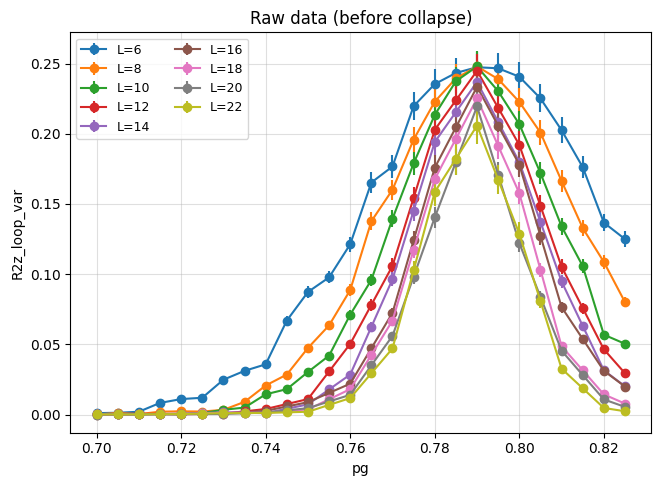

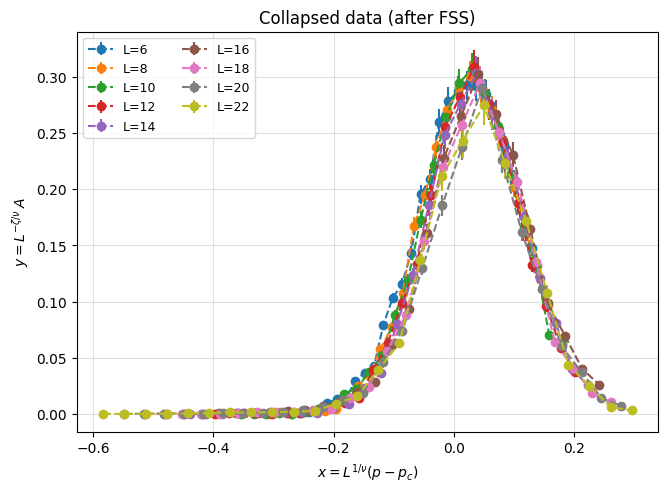

Saved: fig/R2x_loop_var_raw.png fig/R2x_loop_var_collapse.png


In [2]:
import numpy as np, glob, re
import fssa

# ===== 1) 読み込み・Lごとに集約 =====
files = glob.glob("results_px_*_Lx_*_Nd_*_NT_*.npz")
by_L = {}
for fn in files:
    m = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)", fn)
    if not m: 
        continue
    Lx = int(m.group(1))
    dat = np.load(fn)
    if not {"pg","R2z_loop_var","R2z_loop_var_err"}.issubset(set(dat.files)):
        continue
    pg  = np.asarray(dat["pg"], float)
    A   = np.asarray(dat["R2z_loop_var"], float)
    dA  = np.asarray(dat["R2z_loop_var_err"], float)
    by_L[Lx] = (pg, A, dA)

# サイズ配列
Ls = sorted(by_L.keys())
l  = np.array(Ls, float)
if len(Ls) < 2:
    raise RuntimeError("L が2つ以上必要です。")

# ===== 2) 共通 pg グリッドを作って補間 =====
# 代表グリッド（点数が最大のもの）
#rep_pg = max((len(v[0]), v[0]) for v in by_L.values())[1]
#rho = rep_pg.copy()

# 置き換え案1（代表グリッド）
#rep_pg = max((v[0] for v in by_L.values()), key=lambda arr: arr.size)
#rho = np.asarray(rep_pg, float).copy()

# 置き換え案2（ユニオングリッド）
rep_pg = max((v[0] for v in by_L.values()), key=lambda arr: arr.size)
rho = np.unique(np.concatenate([np.asarray(v[0], float) for v in by_L.values()]))



A_rows, dA_rows = [], []
for L in Ls:
    pg, A, dA = by_L[L]
    if np.array_equal(pg, rho):
        Ai, dAi = A, dA
    else:
        # 範囲外は NaN にし、後で列マスク
        Ai  = np.interp(rho, pg, A,  left=np.nan, right=np.nan)
        dAi = np.interp(rho, pg, dA, left=np.nan, right=np.nan)
        # 補間が効かない端は NaNのまま
        xmin, xmax = pg.min(), pg.max()
        mask_out = (rho < xmin) | (rho > xmax)
        Ai[mask_out]  = np.nan
        dAi[mask_out] = np.nan
    A_rows.append(Ai)
    dA_rows.append(dAi)

A_mat_all  = np.vstack(A_rows)   # (nL, nPg)
dA_mat_all = np.vstack(dA_rows)

# ===== 3) 全Lで有効な列だけ残す & 誤差にフロア =====
finite_A = np.isfinite(A_mat_all)
finite_D = np.isfinite(dA_mat_all)
positive_D = np.greater(dA_mat_all, 0, where=finite_D, out=np.zeros_like(finite_D, bool))
common = np.all(finite_A & finite_D & positive_D, axis=0)

rho_use = rho[common]
A_use   = A_mat_all[:, common]
dA_use  = dA_mat_all[:, common]

# 誤差フロア（相対3% + 絶対微小）で数値安定化
rel = 0.03
abs_floor = np.nanmedian(np.abs(A_use)) * 1e-6 if np.isfinite(A_use).any() else 1e-12
dA_use = np.maximum(dA_use, rel*np.abs(A_use) + abs_floor)

# ===== 4) 初期値推定（pc0, nu0, zeta0） =====
nu0 = 1.30
argmax_idx = np.nanargmax(A_use, axis=1)
pg_max = rho_use[argmax_idx]
coef = np.polyfit(1.0/l, pg_max, 1)   # 1/L 外挿
pc0 = float(np.polyval(coef, 0.0))

peak_vals = A_use[np.arange(len(l)), argmax_idx]
slope, _ = np.polyfit(np.log(l), np.log(np.clip(peak_vals, 1e-12, None)), 1)
zeta0 = float(slope * nu0)

# x 窓（各Lのピークが入る最小幅に余裕を足す）
x_need = np.abs((l**(1.0/nu0)) * (pg_max - pc0))
xmax = float(np.nanmax(x_need)+3)
x_bounds = (-xmax, xmax)

# ===== 5) autoscale 実行（最小構成） =====
res = fssa.autoscale(l, rho_use, A_use, dA_use,
                     rho_c0=pc0, nu0=nu0, zeta0=zeta0,
                     x_bounds=x_bounds)

pc, nu, zeta = float(res["rho"]), float(res["nu"]), float(res["zeta"])
dpc, dnu, dzeta = map(float, res["errors"])
print("=== FSS (simple) ===")
print(f"pc   = {pc:.6f} ± {dpc if np.isfinite(dpc) else np.nan}")
print(f"nu   = {nu:.6f} ± {dnu if np.isfinite(dnu) else np.nan}")
print(f"zeta = {zeta:.6f} ± {dzeta if np.isfinite(dzeta) else np.nan}")
print("x_bounds =", x_bounds)

# ===== 6) 可視化：生データとコラプス後を表示＋保存 =====
import matplotlib.pyplot as plt
from pathlib import Path

outdir = Path("fig"); outdir.mkdir(exist_ok=True)

def save_and_show(fig, filename, dpi=300):
    """画像を保存→表示→クローズ（Jupyterでも確実に出る）"""
    fig.savefig(outdir/filename, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# (a) 生データ: A(pg) を Lごとに
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for i, Lval in enumerate(l.astype(int)):
    ax.errorbar(rho_use, A_use[i], dA_use[i], fmt='o-',label=f"L={Lval}")
ax.set_xlabel("pg")
ax.set_ylabel("R2z_loop_var")
ax.set_title("Raw data (before collapse)")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.4)
save_and_show(fig, "R2x_loop_var_raw.png")

# (b) コラプス後: y vs x を Lごとに
scaled = fssa.scaledata(l=l, rho=rho_use, a=A_use, da=dA_use,
                        rho_c=pc, nu=nu, zeta=zeta)
x, y, dy = scaled.x, scaled.y, scaled.dy   # 形 (nL, nPg)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
for i, Lval in enumerate(l.astype(int)):
    ax.errorbar(x[i], y[i], dy[i], fmt='o--',label=f"L={Lval}")
ax.set_xlabel(r"$x = L^{1/\nu}(p - p_c)$")
ax.set_ylabel(r"$y = L^{-\zeta/\nu} \, A$")
ax.set_title("Collapsed data (after FSS)")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.4)
save_and_show(fig, "R2x_loop_var_collapse.png")

print("Saved:",
      outdir/"R2x_loop_var_raw.png",
      outdir/"R2x_loop_var_collapse.png")


/home/kataoka/anaconda3/envs/pyfssa_env/lib/python3.8/site-packages/fssa/fssa.py:165: RuntimeWarning: rho_c is out of range
  warnings.warn("rho_c is out of range", RuntimeWarning)


=== FSS (var) from *_with_err.npz ===
pc   = 0.786272 ± 0.002424127185452837
nu   = 1.445494 ± 0.13880054962730315
zeta = -0.165223 ± 0.15633872540794191
S    = 6.822533


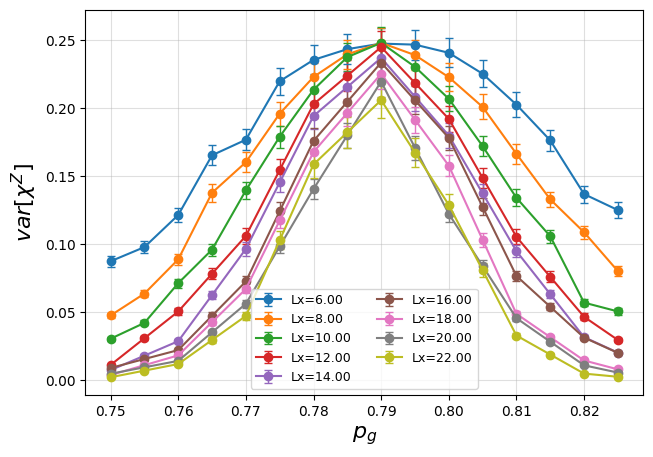

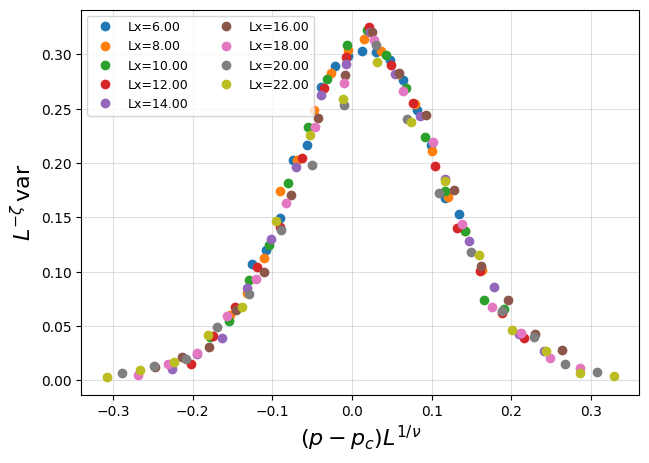

Saved: fig/var_raw.png, fig/var_collapse.png


In [12]:
import numpy as np, glob, re
import matplotlib.pyplot as plt
from pathlib import Path
import fssa

# ======================
# ユーザー設定（必要に応じて調整）
# ======================
use_by_value = True          # True にすると p の値で範囲選択
pmin, pmax   = 0.75, 0.875     # use_by_value=True のときだけ有効
use_sqrtL    = False          # L を sqrt(Lx) にするなら True（セル数~面積が L^2 の時など）

rel_err_floor = 0.03          # 誤差の相対フロア
abs_floor_scale = 1e-6        # 絶対フロアのスケール（中央値×この値）

# ======================
# 1) 読み込み（Lx を抽出）
# ======================
files = glob.glob("results_px_*_Lx_*_Nd_*_NT_*_with_err.npz")
if not files:
    raise FileNotFoundError("マッチする npz が見つかりません。パターンやカレントディレクトリを確認してください。")

by_L = {}  # L : (pg, var, var_err)
for fn in files:
    m = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)", fn)
    if not m:
        continue
    Lx = int(m.group(1))
    dat = np.load(fn)
    if not {"pg","R2z_loop_var","R2z_loop_var_err"}.issubset(dat.files):
        continue
    pg      = np.asarray(dat["pg"], float)
    var     = np.asarray(dat["R2z_loop_var"], float)
    var_err = np.asarray(dat["R2z_loop_var_err"], float)
    by_L[Lx] = (pg, var, var_err)

if len(by_L) < 2:
    raise RuntimeError("異なる L（少なくとも2つ）が必要です。")

Ls = sorted(by_L.keys())
L_arr = np.array(Ls, float)
if use_sqrtL:
    L_arr = np.sqrt(L_arr)

# ======================
# 2) 共通 pg グリッドを作って補間（端は NaN）
# ======================
rho_all = np.unique(np.concatenate([by_L[L][0].astype(float) for L in Ls]))
A_rows, dA_rows = [], []
for L in Ls:
    pg, A, dA = by_L[L]
    pg = np.asarray(pg, float); A = np.asarray(A, float); dA = np.asarray(dA, float)
    if np.array_equal(pg, rho_all):
        Ai, dAi = A.copy(), dA.copy()
    else:
        Ai  = np.interp(rho_all, pg, A,  left=np.nan, right=np.nan)
        dAi = np.interp(rho_all, pg, dA, left=np.nan, right=np.nan)
        xmin, xmax = float(pg.min()), float(pg.max())
        out = (rho_all < xmin) | (rho_all > xmax)
        Ai[out]  = np.nan
        dAi[out] = np.nan
    A_rows.append(Ai); dA_rows.append(dAi)

A_mat  = np.vstack(A_rows)      # 形 (nL, nP)
dA_mat = np.vstack(dA_rows)

# L 全てで有効 & dA>0 の列だけを残す
common = np.all(np.isfinite(A_mat) & np.isfinite(dA_mat) & (dA_mat > 0), axis=0)
rho = rho_all[common]
A   = A_mat[:, common]
dA  = dA_mat[:, common]

if rho.size < 3:
    raise RuntimeError("共通の p 点が少なすぎます。入力データの重なりを確認してください。")

# （任意）p 範囲でさらに絞る
if use_by_value:
    m = (rho >= pmin) & (rho <= pmax)
    if not np.any(m):
        raise ValueError("指定した p 範囲に共通点がありません。pmin/pmax を見直してください。")
    rho, A, dA = rho[m], A[:, m], dA[:, m]

# 誤差の下限（相対 + 絶対）で安定化
abs_floor = (np.nanmedian(np.abs(A)) * abs_floor_scale) if np.isfinite(A).any() else 1e-12
dA = np.maximum(dA, rel_err_floor*np.abs(A) + abs_floor)

# ======================
# 3) 初期値推定（pc0, nu0, zeta0）
# ======================
nu0 = 1.30
argmax_idx = np.nanargmax(A, axis=1)              # 各 L のピーク位置インデックス
pg_max = rho[argmax_idx]
pc0 = float(np.polyval(np.polyfit(1.0/L_arr, pg_max, 1), 0.0))

peak_vals = A[np.arange(len(L_arr)), argmax_idx]
slope = float(np.polyfit(np.log(L_arr), np.log(np.clip(peak_vals, 1e-300, None)), 1)[0])
zeta0 = slope * nu0

# x の探索幅（ピークが入る最小幅 + マージン）
x_need = np.abs((L_arr**(1.0/nu0)) * (pg_max - pc0))
xmax = float(np.nanmax(x_need) + 3.0)
x_bounds = (-xmax, xmax)

# ======================
# 4) autoscale 実行
# ======================
ret = fssa.autoscale(L_arr, rho, A, dA,
                     rho_c0=pc0, nu0=nu0, zeta0=zeta0,
                     x_bounds=x_bounds)

pc, nu, zeta = float(ret.rho), float(ret.nu), float(ret.zeta)
dpc, dnu, dzeta = float(ret.drho), float(ret.dnu), float(ret.dzeta)

# 縮約データと評価関数 S
xs, ys, dys = fssa.scaledata(L_arr, rho, A, dA, pc, nu, zeta)
S = fssa.quality(xs, ys, dys)

print("=== FSS (var) from *_with_err.npz ===")
print(f"pc   = {pc:.6f} ± {dpc if np.isfinite(dpc) else np.nan}")
print(f"nu   = {nu:.6f} ± {dnu if np.isfinite(dnu) else np.nan}")
print(f"zeta = {zeta:.6f} ± {dzeta if np.isfinite(dzeta) else np.nan}")
print(f"S    = {S:.6f}")
if hasattr(ret, "S"):
    print(f"S (autoscale) = {ret.S}")

# ======================
# 5) 可視化
# ======================
outdir = Path("fig"); outdir.mkdir(exist_ok=True)

# Raw
fig, ax = plt.subplots(figsize=(7.2,5))
for i, Lval in enumerate(L_arr):
    ax.errorbar(rho, A[i], dA[i], fmt='o-', capsize=3, elinewidth=1, capthick=1, label=f"Lx={Lval:.2f}")
ax.set_xlabel("$p_g$",fontsize=16); ax.set_ylabel("$var[\chi^{Z}]$",fontsize=16)
#ax.set_title("Raw (var)")
ax.legend(ncol=2, fontsize=9); ax.grid(True, alpha=0.4)
plt.show()
fig.savefig(outdir/"var_raw.png", dpi=300, bbox_inches="tight"); plt.close(fig)

# Collapse
fig, ax = plt.subplots(figsize=(7.2,5))
for i, Lval in enumerate(L_arr):
    #ax.errorbar(xs[i], ys[i], dys[i], fmt='o', label=f"L={Lval:.2f}")
    ax.plot(xs[i], ys[i], 'o', label=f"Lx={Lval:.2f}")
ax.set_xlabel(r"$(p - p_c)L^{1/\nu}$",fontsize=16)
ax.set_ylabel(r"$L^{-\zeta}\,\mathrm{var}$",fontsize=16)
#ax.set_title(f"Collapsed var (S={S:.3f})")
ax.legend(ncol=2, fontsize=9); ax.grid(True, alpha=0.4)
plt.show()
fig.savefig(outdir/"var_collapse.png", dpi=300, bbox_inches="tight"); plt.close(fig)

print("Saved: fig/var_raw.png, fig/var_collapse.png")
